In [1]:
import pandas as pd


In [2]:
dataframe = pd.read_csv("Zomato data .csv")
print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [3]:
import matplotlib as mp
import numpy as np
import seaborn as sns

# convert data frame column of rate

In [4]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
dataframe['rate'] = dataframe['rate'].apply(handleRate)
print(dataframe.head())


                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# Type of restaurant majority customers order from


Text(0.5, 0, 'type of restaurant')

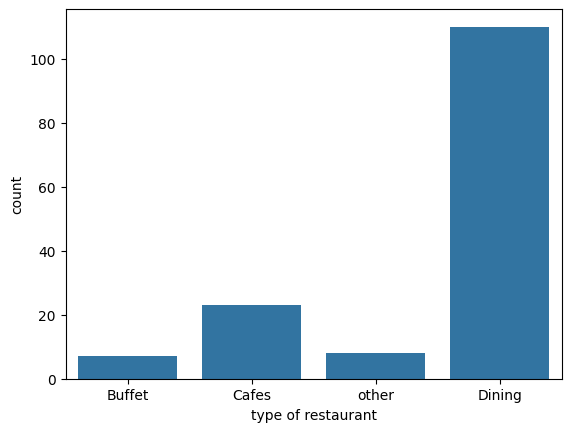

In [5]:
from matplotlib import pyplot as plt
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel('type of restaurant')


# conclusion: Majority of restaurant falls in dinning category


# vote trend for each type of restaurant received from customer


Text(0, 0.5, 'votes')

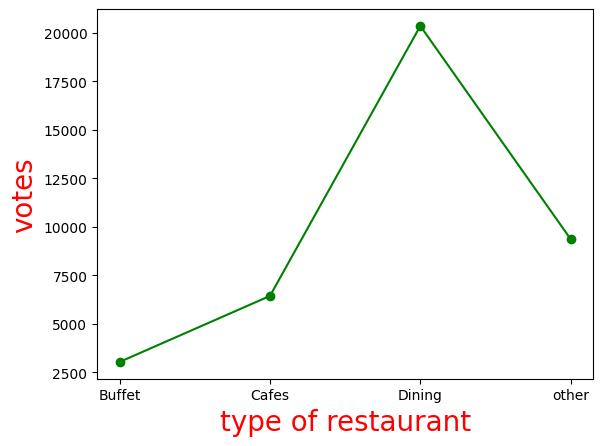

In [6]:
groupeddata=dataframe.groupby("listed_in(type)")["votes"].sum()
result=pd.DataFrame({"votes":groupeddata})
plt.plot(result,c="green",marker='o')
plt.xlabel("type of restaurant",c="red",size=20)
plt.ylabel("votes",c="red",size=20)


# what are the ratings that majority restaurants have received


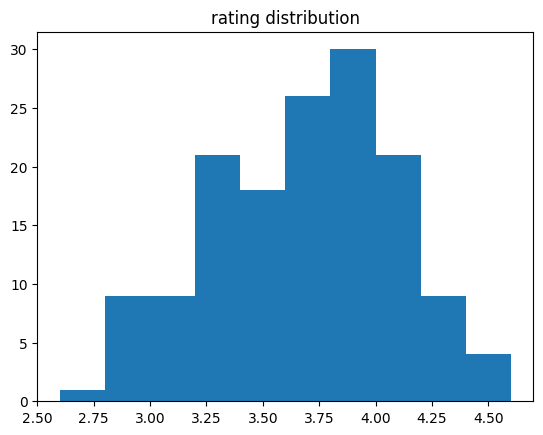

In [8]:
plt.hist(dataframe['rate'],bins=10)
plt.title("rating distribution")
plt.show()


# conclusion : majority restaurants get rated between 3.75 to 4


# Average spending of money by couples


C:\Users\divya.biyani\AppData\Local\Temp\ipykernel_20952\1891187215.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['approx_cost(for two people)'], palette='viridis')


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

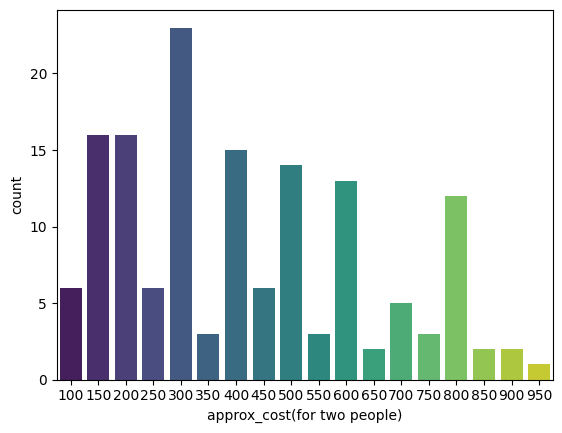

In [10]:
sns.countplot(x=dataframe['approx_cost(for two people)'], palette='viridis')


# majority of couples prefer restaurants with approx cost of 300 rs



# which mode has received maximum rating


<Axes: xlabel='online_order', ylabel='rate'>

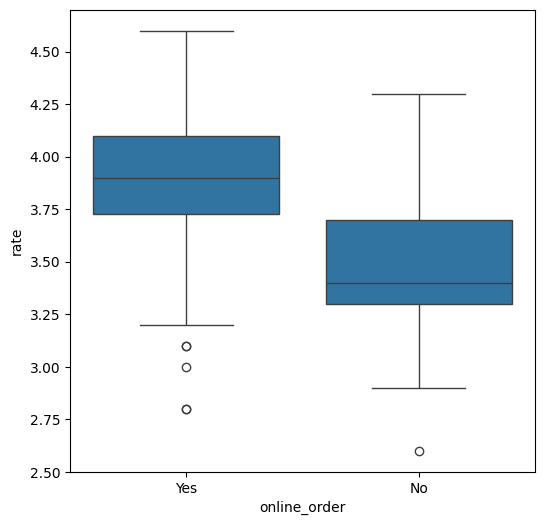

In [11]:
plt.figure(figsize= (6,6))
sns.boxplot(x='online_order',y='rate',data=dataframe)


# offline order received lower ratings compared to online order


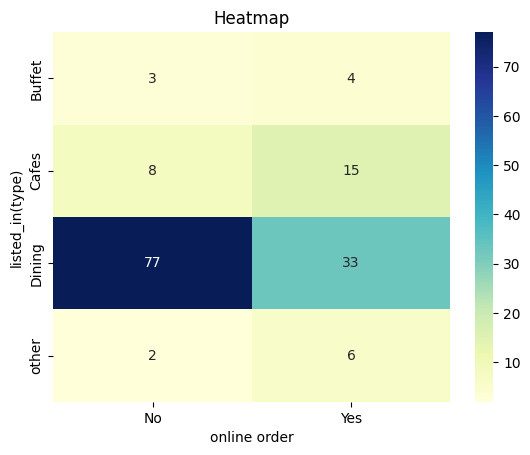

In [15]:
pivot_table=dataframe.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap="YlGnBu",fmt='d')
plt.title("Heatmap")
plt.xlabel("online order")
plt.ylabel("listed_in(type)")
plt.show()



# conclusion: Dining restaurants primariliy accept offline orders,whereas cafes primariliy receive online orders.This shows that people prefer to eat in person in dinning restaurants whereas online mode in cafe
